# 05: 匿名化の定量評価(並列実行)

UTKFaceの画像群に対し，スケール係数(`noise_level`)ごとに匿名化前後の年齢・性別・ArcFaceの
コサイン類似度を計測する．`identity_anonymizer.evaluation.run_evaluation_parallel` により，
複数プロセスで並列に評価する．

プロセス数を明示的に指定しない場合，`determine_worker_count` が「1プロセスで実際に1回処理した
際のDRAM/VRAM使用量」を計測したうえで，使用可能なメモリに収まる範囲で自動的に決定する．

**注意:** `run_evaluation_parallel` / `determine_worker_count` は内部で
`multiprocessing`(spawnコンテキスト)を使用する．notebookから直接呼び出す場合はこの制約を
受けないが，本notebookのコードをスクリプト化する場合は `if __name__ == "__main__":` の
内側から呼び出す必要がある．


In [1]:
import os
import sys

# notebooks/ から見て1階層上がリポジトリルート
REPO_ROOT = os.path.dirname(os.getcwd())
sys.path.insert(0, os.path.join(REPO_ROOT, "src"))
os.chdir(REPO_ROOT)

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

_jp_font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
if os.path.exists(_jp_font_path):
    fm.fontManager.addfont(_jp_font_path)
    plt.rcParams["font.family"] = "Noto Sans CJK JP"
    plt.rcParams["axes.unicode_minus"] = False


In [2]:
from identity_anonymizer import config
from identity_anonymizer.data import list_utkface_image_paths
from identity_anonymizer.evaluation import determine_worker_count, run_evaluation_parallel

VAE_WEIGHT_PATH = os.path.join(config.ANONYMIZER_WEIGHTS_DIR, "vae", "vae_512_128.pt")
IMAGE_DIR = "data/utkface_sample"  # UTKFace全件で評価する場合は "data/UTKFace" 等に変更する

image_paths = list_utkface_image_paths(IMAGE_DIR)
print(f"評価対象画像数: {len(image_paths)}")


評価対象画像数: 500


/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/kornia/augmentation/augmentation.py:1830: DeprecationWarning: GaussianBlur is no longer maintained and will be removed from the future versions. Please use RandomGaussianBlur instead.
  warnings.warn(


## 逐次実行と並列実行の整合性確認

少数サンプルに対し，逐次実行(1プロセス)と並列実行(複数プロセス)の結果を比較し，集計値
(平均コサイン類似度・性別一致率)が同程度になることを確認する．VAEのサンプリングは確率的であり
プロセスごとに乱数系列が異なるため，画像単位での厳密な一致ではなく，集計値の一致度で検証する．


In [3]:
import time

from identity_anonymizer.anonymizers import get_anonymizer
from identity_anonymizer.evaluation import evaluate_single_image, load_dex_models
from identity_anonymizer.faceswap import FaceAnonymizerPipeline, load_ghost_models


def summarize(results):
    """
    評価結果のリストから，コサイン類似度の平均と性別の一致率を集計する．

    引数:
        results (list[AnonymizationEvalResult]): 評価結果のリスト．
    戻り値:
        summary (dict): "mean_cosine_similarity", "gender_match_rate", "n" を含む辞書．
    """
    n = len(results)
    mean_cossim = sum(r.cosine_similarity for r in results) / n
    gender_match_rate = sum(r.original_gender == r.anonymized_gender for r in results) / n
    return {"mean_cosine_similarity": mean_cossim, "gender_match_rate": gender_match_rate, "n": n}


CHECK_NOISE_LEVEL = 1.25
check_image_paths = image_paths[:20]

models = load_ghost_models()
anonymizer = get_anonymizer("vae", weight_path=VAE_WEIGHT_PATH)
pipeline = FaceAnonymizerPipeline(models, anonymizer)
dex_models = load_dex_models(device="cuda")

t0 = time.time()
sequential_results = [
    r for r in (evaluate_single_image(p, pipeline, dex_models, noise_level=CHECK_NOISE_LEVEL) for p in check_image_paths)
    if r is not None
]
sequential_time = time.time() - t0
print(f"逐次実行: {sequential_time:.1f}s, {summarize(sequential_results)}")


input mean and std: 127.5 127.5
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/glintr100.onnx recognition
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/scrfd_10g_bnkps.onnx detection
set det-size: (640, 640)
loading /home/yryo1005/workspace/identity-anonymizer/weights/ghost/2d106det 0
input mean and std: 127.5 127.5
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/glintr100.onnx recognition
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/scrfd_10g_bnkps.onnx detection
set det-size: (640, 640)


[11:08:03] ../src/nnvm/legacy_json_util.cc:208: Loading symbol saved by previous version v1.5.0. Attempting to upgrade...
[11:08:03] ../src/nnvm/legacy_json_util.cc:216: Symbol successfully upgraded!
[11:08:03] ../src/base.cc:79: cuDNN lib mismatch: linked-against version 8302 != compiled-against version 8101.  Set MXNET_CUDNN_LIB_CHECKING=0 to quiet this warning.
/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/mxnet/ndarray/utils.py:141: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  if spsp is not None and isinstance(source_array, spsp.csr.csr_matrix):
[11:08:07] ../src/operator/nn/./cudnn/./cudnn_algoreg-inl.h:96: Running performance tests to find the best convolution algorithm, this can take a while... (set the environment variable MXNET_CUDNN_AUTOTUNE_DEFAULT to 0 to disable)
/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/mxnet/ndarray/utils.py:141: De

Video doesn't contain face!
顔を検出できませんでした．別の画像を使用してください．


/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/mxnet/ndarray/utils.py:141: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  if spsp is not None and isinstance(source_array, spsp.csr.csr_matrix):
/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/mxnet/ndarray/utils.py:141: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  if spsp is not None and isinstance(source_array, spsp.csr.csr_matrix):
/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/mxnet/ndarray/utils.py:141: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  if spsp is not None and isinstance(source_array, spsp.csr.csr_matrix):
/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/mxnet/ndarray/utils.py:141: 

Video doesn't contain face!
顔を検出できませんでした．別の画像を使用してください．
Video doesn't contain face!
顔を検出できませんでした．別の画像を使用してください．


/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/mxnet/ndarray/utils.py:141: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  if spsp is not None and isinstance(source_array, spsp.csr.csr_matrix):
/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/mxnet/ndarray/utils.py:141: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  if spsp is not None and isinstance(source_array, spsp.csr.csr_matrix):
/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/mxnet/ndarray/utils.py:141: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  if spsp is not None and isinstance(source_array, spsp.csr.csr_matrix):
/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/mxnet/ndarray/utils.py:141: 

逐次実行: 7.4s, {'mean_cosine_similarity': 0.6686563000959509, 'gender_match_rate': 0.8823529411764706, 'n': 17}


/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/mxnet/ndarray/utils.py:141: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  if spsp is not None and isinstance(source_array, spsp.csr.csr_matrix):
/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/mxnet/ndarray/utils.py:141: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  if spsp is not None and isinstance(source_array, spsp.csr.csr_matrix):


In [4]:
if __name__ == "__main__":
    t0 = time.time()
    num_workers = determine_worker_count(
        config.GHOST_WEIGHTS_DIR, config.DEX_WEIGHTS_DIR, "vae", VAE_WEIGHT_PATH,
        sample_image_paths=check_image_paths[:3], noise_level=CHECK_NOISE_LEVEL,
    )
    print(f"自動決定されたプロセス数: {num_workers}")

    parallel_results = run_evaluation_parallel(
        check_image_paths, config.GHOST_WEIGHTS_DIR, config.DEX_WEIGHTS_DIR,
        anonymizer_name="vae", anonymizer_weight_path=VAE_WEIGHT_PATH,
        noise_level=CHECK_NOISE_LEVEL, num_workers=num_workers,
    )
    parallel_time = time.time() - t0
    print(f"並列実行({num_workers}プロセス): {parallel_time:.1f}s, {summarize(parallel_results)}")
    print(f"高速化率: {sequential_time / parallel_time:.2f}倍")


/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/kornia/augmentation/augmentation.py:1830: DeprecationWarning: GaussianBlur is no longer maintained and will be removed from the future versions. Please use RandomGaussianBlur instead.
  warnings.warn(
[11:08:20] ../src/nnvm/legacy_json_util.cc:208: Loading symbol saved by previous version v1.5.0. Attempting to upgrade...
[11:08:20] ../src/nnvm/legacy_json_util.cc:216: Symbol successfully upgraded!
[11:08:20] ../src/base.cc:79: cuDNN lib mismatch: linked-against version 8302 != compiled-against version 8101.  Set MXNET_CUDNN_LIB_CHECKING=0 to quiet this warning.
/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/mxnet/ndarray/utils.py:141: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  if spsp is not None and isinstance(source_array, spsp.csr.csr_matrix):
[11:08:24] ../src/operator/nn/./cudnn/./cudnn_algoreg-inl.h:

input mean and std: 127.5 127.5
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/glintr100.onnx recognition
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/scrfd_10g_bnkps.onnx detection
set det-size: (640, 640)
loading /home/yryo1005/workspace/identity-anonymizer/weights/ghost/2d106det 0
input mean and std: 127.5 127.5
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/glintr100.onnx recognition
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/scrfd_10g_bnkps.onnx detection
set det-size: (640, 640)
自動決定されたプロセス数: 2


/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/kornia/augmentation/augmentation.py:1830: DeprecationWarning: GaussianBlur is no longer maintained and will be removed from the future versions. Please use RandomGaussianBlur instead.
  warnings.warn(
/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/kornia/augmentation/augmentation.py:1830: DeprecationWarning: GaussianBlur is no longer maintained and will be removed from the future versions. Please use RandomGaussianBlur instead.
  warnings.warn(
[11:08:34] ../src/nnvm/legacy_json_util.cc:208: Loading symbol saved by previous version v1.5.0. Attempting to upgrade...
[11:08:34] ../src/nnvm/legacy_json_util.cc:216: Symbol successfully upgraded!
[11:08:34] ../src/base.cc:79: cuDNN lib mismatch: linked-against version 8302 != compiled-against version 8101.  Set MXNET_CUDNN_LIB_CHECKING=0 to quiet this warning.
[11:08:34] ../src/nnvm/legacy_json_util.cc:208: Loading symbol saved by previous versio

input mean and std: 127.5 127.5
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/glintr100.onnx recognition
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/scrfd_10g_bnkps.onnx detection
set det-size: (640, 640)
loading /home/yryo1005/workspace/identity-anonymizer/weights/ghost/2d106det 0
input mean and std: 127.5 127.5
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/glintr100.onnx recognition
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/scrfd_10g_bnkps.onnx detection
set det-size: (640, 640)
Video doesn't contain face!
顔を検出できませんでした．別の画像を使用してください．
Video doesn't contain face!
顔を検出できませんでした．別の画像を使用してください．
input mean and std: 127.5 127.5
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/glintr100.onnx recognition
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/scrfd_10g_bnkps.onnx detection
set det-si

## スケール係数ごとの定量評価

`references/` の予稿と同様に，スケール係数(`noise_level`)を変化させたときの
「年齢のRMSE」「性別の一致率」「コサイン類似度」を計測する．


In [5]:
import numpy as np

NOISE_LEVELS = [0.0, 1.0, 1.25, 1.5, 2.0]

rows = []
if __name__ == "__main__":
    for noise_level in NOISE_LEVELS:
        num_workers = determine_worker_count(
            config.GHOST_WEIGHTS_DIR, config.DEX_WEIGHTS_DIR, "vae", VAE_WEIGHT_PATH,
            sample_image_paths=image_paths[:3], noise_level=noise_level,
        )
        results = run_evaluation_parallel(
            image_paths, config.GHOST_WEIGHTS_DIR, config.DEX_WEIGHTS_DIR,
            anonymizer_name="vae", anonymizer_weight_path=VAE_WEIGHT_PATH,
            noise_level=noise_level, num_workers=num_workers,
        )

        age_rmse = float(np.sqrt(np.mean([(r.original_age - r.anonymized_age) ** 2 for r in results])))
        gender_match_rate = float(np.mean([r.original_gender == r.anonymized_gender for r in results]))
        mean_cossim = float(np.mean([r.cosine_similarity for r in results]))

        rows.append({
            "noise_level": noise_level,
            "n": len(results),
            "age_rmse": age_rmse,
            "gender_match_rate": gender_match_rate,
            "mean_cosine_similarity": mean_cossim,
        })
        print(rows[-1])


/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/kornia/augmentation/augmentation.py:1830: DeprecationWarning: GaussianBlur is no longer maintained and will be removed from the future versions. Please use RandomGaussianBlur instead.
  warnings.warn(
[11:08:51] ../src/nnvm/legacy_json_util.cc:208: Loading symbol saved by previous version v1.5.0. Attempting to upgrade...
[11:08:51] ../src/nnvm/legacy_json_util.cc:216: Symbol successfully upgraded!
[11:08:51] ../src/base.cc:79: cuDNN lib mismatch: linked-against version 8302 != compiled-against version 8101.  Set MXNET_CUDNN_LIB_CHECKING=0 to quiet this warning.
/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/mxnet/ndarray/utils.py:141: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  if spsp is not None and isinstance(source_array, spsp.csr.csr_matrix):
[11:08:54] ../src/operator/nn/./cudnn/./cudnn_algoreg-inl.h:

input mean and std: 127.5 127.5
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/glintr100.onnx recognition
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/scrfd_10g_bnkps.onnx detection
set det-size: (640, 640)
loading /home/yryo1005/workspace/identity-anonymizer/weights/ghost/2d106det 0
input mean and std: 127.5 127.5
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/glintr100.onnx recognition
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/scrfd_10g_bnkps.onnx detection
set det-size: (640, 640)


/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/kornia/augmentation/augmentation.py:1830: DeprecationWarning: GaussianBlur is no longer maintained and will be removed from the future versions. Please use RandomGaussianBlur instead.
  warnings.warn(
/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/kornia/augmentation/augmentation.py:1830: DeprecationWarning: GaussianBlur is no longer maintained and will be removed from the future versions. Please use RandomGaussianBlur instead.
  warnings.warn(
[11:09:05] ../src/nnvm/legacy_json_util.cc:208: Loading symbol saved by previous version v1.5.0. Attempting to upgrade...
[11:09:05] ../src/nnvm/legacy_json_util.cc:216: Symbol successfully upgraded!
[11:09:05] ../src/base.cc:79: cuDNN lib mismatch: linked-against version 8302 != compiled-against version 8101.  Set MXNET_CUDNN_LIB_CHECKING=0 to quiet this warning.
[11:09:05] ../src/nnvm/legacy_json_util.cc:208: Loading symbol saved by previous versio

input mean and std: 127.5 127.5
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/glintr100.onnx recognition
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/scrfd_10g_bnkps.onnx detection
set det-size: (640, 640)
loading /home/yryo1005/workspace/identity-anonymizer/weights/ghost/2d106det 0
input mean and std: 127.5 127.5
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/glintr100.onnx recognition
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/scrfd_10g_bnkps.onnx detection
set det-size: (640, 640)
Video doesn't contain face!
顔を検出できませんでした．別の画像を使用してください．
Video doesn't contain face!
顔を検出できませんでした．別の画像を使用してください．
Video doesn't contain face!
顔を検出できませんでした．別の画像を使用してください．
Video doesn't contain face!
顔を検出��きませんでした．別の画像を使用してください．
Video doesn't contain face!
顔を検出できませんでした．別の画像を使用してください．
Video doesn't contain face!
顔を検出できませんでした．別の画像を使用してください．
Video doesn't contain face!
顔を検出できま

/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/kornia/augmentation/augmentation.py:1830: DeprecationWarning: GaussianBlur is no longer maintained and will be removed from the future versions. Please use RandomGaussianBlur instead.
  warnings.warn(
[11:10:23] ../src/nnvm/legacy_json_util.cc:208: Loading symbol saved by previous version v1.5.0. Attempting to upgrade...
[11:10:23] ../src/nnvm/legacy_json_util.cc:216: Symbol successfully upgraded!
[11:10:23] ../src/base.cc:79: cuDNN lib mismatch: linked-against version 8302 != compiled-against version 8101.  Set MXNET_CUDNN_LIB_CHECKING=0 to quiet this warning.
/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/mxnet/ndarray/utils.py:141: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  if spsp is not None and isinstance(source_array, spsp.csr.csr_matrix):
[11:10:27] ../src/operator/nn/./cudnn/./cudnn_algoreg-inl.h:

...

input mean and std: 127.5 127.5
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/glintr100.onnx recognition
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/scrfd_10g_bnkps.onnx detection
set det-size: (640, 640)
loading /home/yryo1005/workspace/identity-anonymizer/weights/ghost/2d106det 0
input mean and std: 127.5 127.5
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/glintr100.onnx recognition
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/scrfd_10g_bnkps.onnx detection
set det-size: (640, 640)
Video doesn't contain face!
顔を検出できませんでした．別の画像を使用してください．
Video doesn't contain face!
顔を検出できませんでした．別の画像を使用してください．
Video doesn't contain face!
顔を検出できませんでした．別の画像を使用してください．
Video doesn't contain face!
顔を検出��きませんでした．別の画像を使用してください．
Video doesn't contain face!
顔を検出できませんでした．別の画像を使用してください．
Video doesn't contain face!
顔を検出できませんでした．別の画像を使用してください．
Video doesn't contain face!
顔を検出できま

/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/kornia/augmentation/augmentation.py:1830: DeprecationWarning: GaussianBlur is no longer maintained and will be removed from the future versions. Please use RandomGaussianBlur instead.
  warnings.warn(
[11:15:07] ../src/nnvm/legacy_json_util.cc:208: Loading symbol saved by previous version v1.5.0. Attempting to upgrade...
[11:15:07] ../src/nnvm/legacy_json_util.cc:216: Symbol successfully upgraded!
[11:15:07] ../src/base.cc:79: cuDNN lib mismatch: linked-against version 8302 != compiled-against version 8101.  Set MXNET_CUDNN_LIB_CHECKING=0 to quiet this warning.
/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/mxnet/ndarray/utils.py:141: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  if spsp is not None and isinstance(source_array, spsp.csr.csr_matrix):
[11:15:10] ../src/operator/nn/./cudnn/./cudnn_algoreg-inl.h:

input mean and std: 127.5 127.5
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/glintr100.onnx recognition
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/scrfd_10g_bnkps.onnx detection
set det-size: (640, 640)
loading /home/yryo1005/workspace/identity-anonymizer/weights/ghost/2d106det 0
input mean and std: 127.5 127.5
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/glintr100.onnx recognition
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/scrfd_10g_bnkps.onnx detection
set det-size: (640, 640)


/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/kornia/augmentation/augmentation.py:1830: DeprecationWarning: GaussianBlur is no longer maintained and will be removed from the future versions. Please use RandomGaussianBlur instead.
  warnings.warn(
/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/kornia/augmentation/augmentation.py:1830: DeprecationWarning: GaussianBlur is no longer maintained and will be removed from the future versions. Please use RandomGaussianBlur instead.
  warnings.warn(
[11:15:21] ../src/nnvm/legacy_json_util.cc:208: Loading symbol saved by previous version v1.5.0. Attempting to upgrade...
[11:15:21] ../src/nnvm/legacy_json_util.cc:216: Symbol successfully upgraded!
[11:15:21] ../src/base.cc:79: cuDNN lib mismatch: linked-against version 8302 != compiled-against version 8101.  Set MXNET_CUDNN_LIB_CHECKING=0 to quiet this warning.
[11:15:21] ../src/nnvm/legacy_json_util.cc:208: Loading symbol saved by previous versio

input mean and std: 127.5 127.5
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/glintr100.onnx recognition
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/scrfd_10g_bnkps.onnx detection
set det-size: (640, 640)
loading /home/yryo1005/workspace/identity-anonymizer/weights/ghost/2d106det 0
input mean and std: 127.5 127.5
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/glintr100.onnx recognition
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/scrfd_10g_bnkps.onnx detection
set det-size: (640, 640)
Video doesn't contain face!
顔を検出できませんでした．別の画像を使用してください．
Video doesn't contain face!
顔を検出できませんでした．別の画像を使用してください．
Video doesn't contain face!
顔を検出できませんでした．別の画像を使用してください．
Video doesn't contain face!
顔を検出��きませんでした．別の画像を使用してください．
Video doesn't contain face!
顔を検出できませんでした．別の画像を使用してください．
Video doesn't contain face!
顔を検出できませんでした．別の画像を使用してください．
Video doesn't contain face!
顔を検出できま

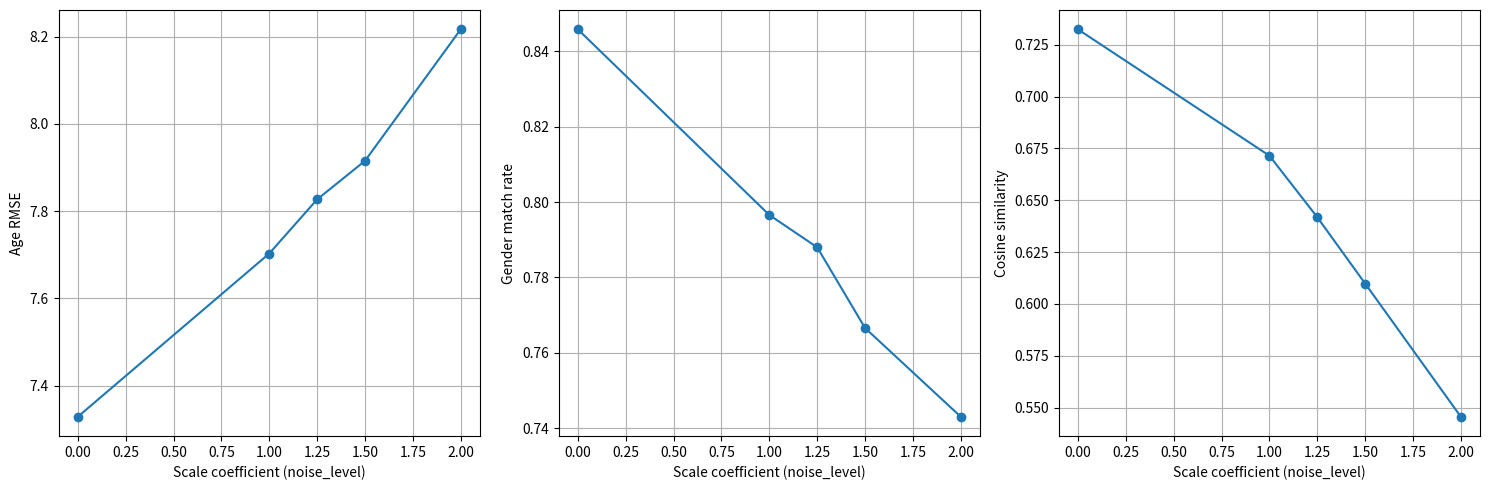

In [6]:
import json

os.makedirs("outputs", exist_ok=True)
with open("outputs/evaluation_results.json", "w") as f:
    json.dump(rows, f, indent=4, ensure_ascii=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot([r["noise_level"] for r in rows], [r["age_rmse"] for r in rows], marker="o")
axes[0].set_xlabel("Scale coefficient (noise_level)")
axes[0].set_ylabel("Age RMSE")
axes[0].grid()

axes[1].plot([r["noise_level"] for r in rows], [r["gender_match_rate"] for r in rows], marker="o")
axes[1].set_xlabel("Scale coefficient (noise_level)")
axes[1].set_ylabel("Gender match rate")
axes[1].grid()

axes[2].plot([r["noise_level"] for r in rows], [r["mean_cosine_similarity"] for r in rows], marker="o")
axes[2].set_xlabel("Scale coefficient (noise_level)")
axes[2].set_ylabel("Cosine similarity")
axes[2].grid()

fig.tight_layout()
fig.savefig("outputs/evaluation_results.png")
plt.show()
